# The SIDM background estimate from first principles — Part 4: the windowed pass, and first results

Part 3 recommended replacing the fixed mJJ ≥ 150 GeV blind box with a sliding
blinded window, so that local background fits can be validated *in the signal
selections themselves*. The analysis owner approved that re-blinding, and this
notebook documents the implementation and the first results of the new data
pass (`AbcdMjjWin_Run2018_v1`; 8,516 of 8,519 chunks = 99.96%; full 2018).

**The blinding scheme.** Three mass windows, **pre-registered from signal
simulation only** (the 68% mJJ cores of the 100/500/1000 GeV grid points,
Part 3 Section 7) before any data look at the newly exposed regions:

| Window | Range [GeV] | Covers |
|---|---|---|
| W100 | [80, 130) | the 100 GeV points (cores [90,110]–[90,130]) |
| W500 | [380, 600) | every 500 GeV point (widest core [390,590]) |
| W1000 | [780, ∞) | the 1000 GeV points (the 9.6 mm point's core reaches ~670; its leakage into the open sideband is an accepted sensitivity loss, not a blinding leak) |

Everything outside the windows — notably [130, 380) and [600, 780) — is now
visible in the pass regions. The vetoes (`ABCD_BLIND_WINDOWS` and the two
`ABCD window blind veto` cuts in `sidm/definitions/cuts.py`) reuse the
fail-closed construction of the fixed boxes; the condor interlock recognizes
them with the same topology pairing; the fixed-box `_data_full` channels and
the staged 10% channels are unchanged. Verified before submission: the
interlock refuses an unprotected data channel, and on a smoke file the
pass-region window bins are exactly empty while everything else fills.

Region names: **SP** = 4mu cleaned both-iso-pass (as in Part 3);
**A/B/C/D** = the four regions of the deployed 2mu2e plane as defined in
Part 1 (Part 3 used the subset A/B/D2; the full four-letter naming is
restored here).

In [1]:
import glob, math
import numpy as np
import coffea.util as cu
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.optimize import minimize
from scipy import stats as st
plt.style.use(hep.style.CMS)

CACHE = "/uscms_data/d3/murtazas/abcd_mjjwin_local"   # merged AbcdMjjWin_Run2018_v1 (see README)
H = {}
nfiles = 0
for f in sorted(glob.glob(CACHE + "/DoubleMuon_*.coffea")):
    o = cu.load(f); o = o.get("out", o)
    for ds in o.values():
        for k in ("abcd_mjjfine_4mu", "abcd_mjjfine_2mu2e"):
            h = ds["hists"][k]
            H[k] = h.copy() if k not in H else H[k] + h
    nfiles += 1
print("summed %d merged data files (full 2018, windowed channels)" % nfiles)

h4 = H["abcd_mjjfine_4mu"][{"channel": "4mu_abcd_scan_data_win"}]
MJ = np.asarray(h4.axes["mjjf"].edges); CTR = 0.5 * (MJ[:-1] + MJ[1:]); CTR[-1] = 1000.
JTOP = len(CTR) - 1
def ei(v): return int(np.argmin(np.abs(MJ - v)))

v4 = h4.view()["value"].sum(axis=-1)                      # (vcat, iso0, iso1, mjj)
SP = v4[1, 0:2, 0:2, :].sum(axis=(0, 1))
h2 = H["abcd_mjjfine_2mu2e"][{"channel": "2mu2e_abcd_scan_data_win"}]
v2 = h2.view()["value"].sum(axis=-1)                      # (vcat, muiso, egmiso, mudisp, dphi2, egmdisp2, mjj)
A2 = v2[:, 0:2, 0:2, 0:2, 1, 1, :].sum(axis=(0, 1, 2, 3))
B2 = v2[:, 0:2, 2, 0:2, 1, 1, :].sum(axis=(0, 1, 2))
Ccol = v2[:, 0:2, 0:2, 2:, 1, 1, :].sum(axis=(0, 1, 2, 3))
Dcol = v2[:, 0:2, 2, 2:, 1, 1, :].sum(axis=(0, 1, 2))

BLIND = ((CTR >= 80) & (CTR < 130)) | ((CTR >= 380) & (CTR < 600)) | (CTR >= 780)
assert SP[BLIND].sum() == 0 and A2[BLIND].sum() == 0, "window-blinding violation"
print("window bins empty in both pass regions (blinding verified on the full merge)")
print("SP visible: %.0f events;  A visible: %.0f events" % (SP.sum(), A2.sum()))

summed 68 merged data files (full 2018, windowed channels)
window bins empty in both pass regions (blinding verified on the full merge)
SP visible: 1722 events;  A visible: 89 events


## 1. The pass-region spectra

The 4mu SP spectrum **turns over at ~130–150 GeV** — just above where the old
blind box began — and falls slowly, staying at ~20 events/bin even at
600–780 GeV. The hard tail is expected from Part 2's finding that the
isolation-pass probability rises with mJJ. The 2mu2e A spectrum falls steeply
above its turnover.

**How to read the figure**: events per 10-GeV bin; grey bands are the three
pre-registered blind windows (the points are absent in the window bins, which
are empty by construction — not zero-suppressed).

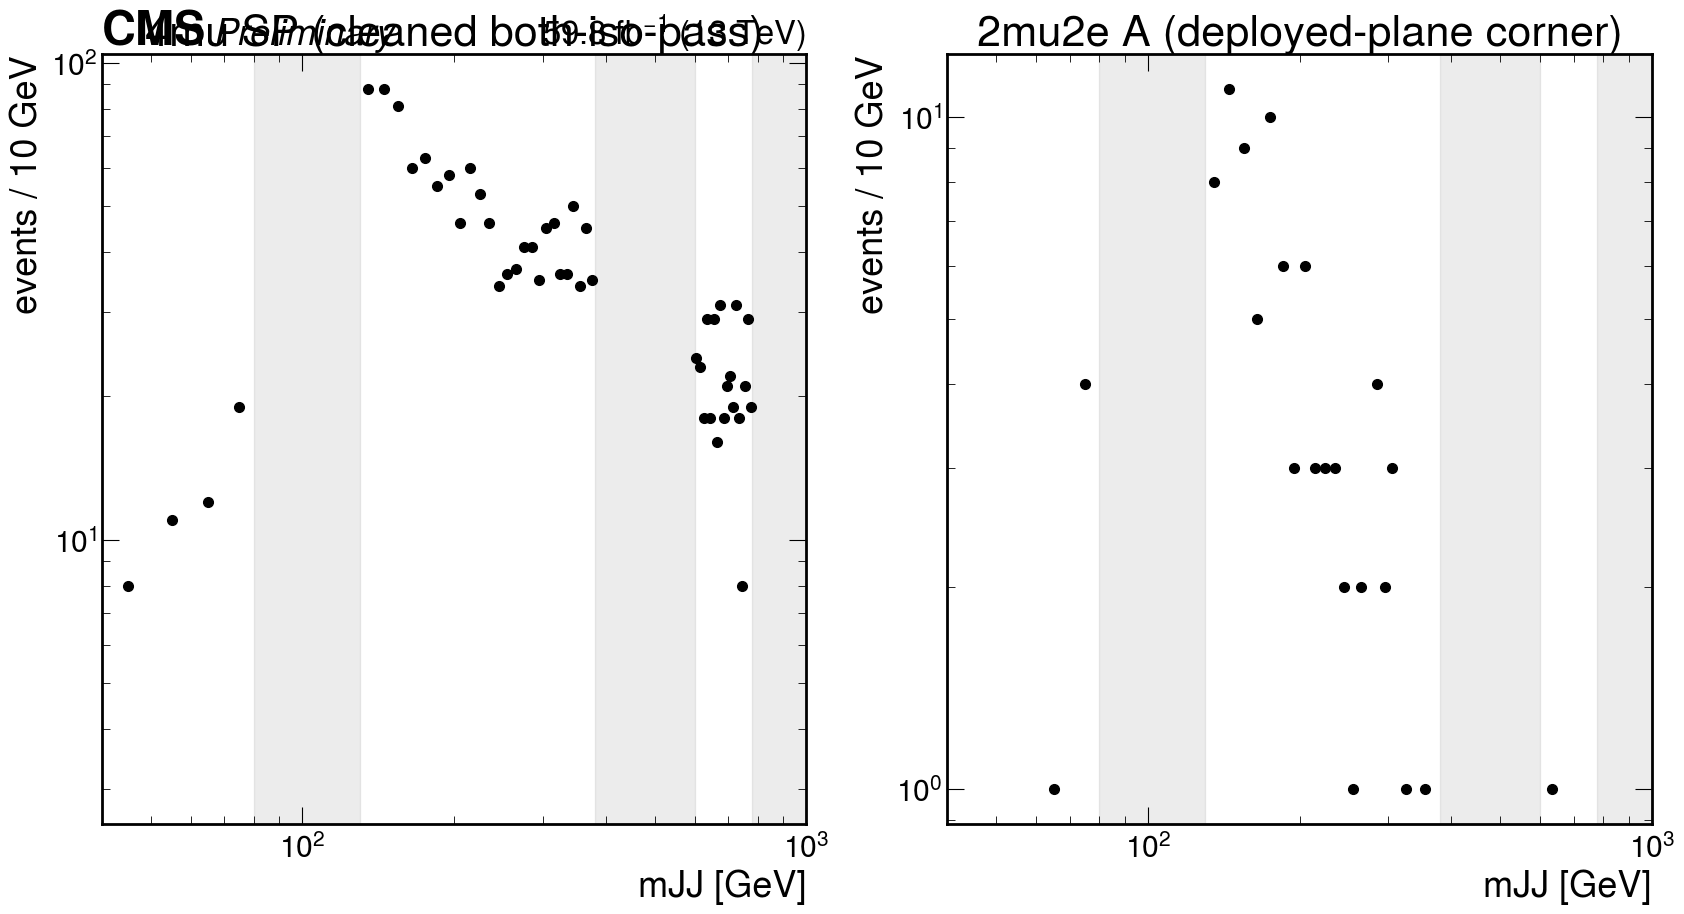

In [2]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
for axp, (c, lab) in zip(axs, ((SP, "4mu SP (cleaned both-iso-pass)"),
                               (A2, "2mu2e A (deployed-plane corner)"))):
    m = (~BLIND) & (c > 0)
    axp.plot(CTR[m], c[m], "o", color="black", ms=7)
    for lo, hi in ((80, 130), (380, 600), (780, 1000)):
        axp.axvspan(lo, hi, color="grey", alpha=0.15)
    axp.set_yscale("log"); axp.set_xscale("log"); axp.set_xlim(40, 1000)
    axp.set_xlabel("mJJ [GeV]"); axp.set_ylabel("events / 10 GeV")
    axp.set_title(lab)
hep.cms.label("Preliminary", data=True, lumi=59.8, ax=axs[0])
plt.show()

## 2. Local-fit validation *in the pass regions*

Part 3 validated the local window fit only in iso-fail regions; the transfer
to the pass regions was flagged as an assumption. It can now be tested
directly, at test masses whose ±100 GeV fit window avoids the blind bins:

* **2mu2e A**: the local prediction matches the observation (z = −0.2, −0.8) —
  the local fit transfers to the pass region as-is.
* **4mu SP**: a negative bias of the same sign and comparable size as in the
  open regions appears here (the fit over-predicts the center by ~6–16%; the
  cell prints the fractional bias next to each test). Consistency of the
  *fractional* bias across regions is what makes a correction (or one-sided
  systematic) of this measured size the right prescription for any deployed
  4mu window estimate; the z-magnitudes themselves differ with the regions'
  statistics.

Caveats carried from Part 3 apply verbatim: the three test masses share most
of their ±100 GeV fit windows (the results are strongly correlated —
effectively one measurement, not three), and the pulls use only the Poisson
error on the predicted count (fit-parameter uncertainty not propagated).

In [3]:
def f_expow(m, p):
    return np.exp(p[0] - abs(p[1]) * m / 100.) * (m / 100.) ** (-p[2])

def masked_fit(counts, ilo, ihi, mask):
    m, n = CTR[ilo:ihi], counts[ilo:ihi]
    def nll(p):
        mu = np.clip(f_expow(m[mask], p) * 10., 1e-9, None)
        return float(np.sum(mu - n[mask] * np.log(mu)))
    p0 = [math.log(max(n[mask].max(), 1) / 10. + 1e-9), 0.5, 1.]
    r = minimize(nll, p0, method="Nelder-Mead", options={"maxiter": 20000, "fatol": 1e-9})
    mu = np.clip(f_expow(m[mask], r.x) * 10., 1e-9, None)
    ok = n[mask] > 0
    c2 = float(np.sum((n[mask][ok] - mu[ok]) ** 2 / mu[ok]))
    return r.x, c2, int(ok.sum() - 3)

print("Fit [M-100,M+100] minus [M-25,M+25], predict the center (pass regions):")
for name, c in (("4mu SP", SP), ("2mu2e A", A2)):
    for M in (230., 250., 280.):
        ilo, ihi = ei(M - 100.), ei(M + 100.)
        if BLIND[ilo:ihi].any(): continue
        mask = np.ones(ihi - ilo, bool)
        mask[ei(M - 25.) - ilo:ei(M + 25.) - ilo] = False
        n = c[ilo:ihi]
        if n[mask].sum() < 40 or n[~mask].sum() < 3:
            print("  %-8s M=%3.0f: too few events" % (name, M)); continue
        pars, c2, ndf = masked_fit(c, ilo, ihi, mask)
        pred = float(np.clip(f_expow(CTR[ilo:ihi][~mask], pars) * 10., 0, None).sum())
        obs = float(n[~mask].sum())
        print("  %-8s M=%3.0f: obs=%5.0f  pred=%7.1f  z=%+.1f  frac bias %+5.1f%%  [sideband chi2/ndf %.1f/%d]"
              % (name, M, obs, pred, (obs - pred) / math.sqrt(max(pred, 1.)),
                 100 * (obs - pred) / pred, c2, ndf))
print("(open-region reference, Part 3: 4mu mean fractional bias ~ -10 to -15%)")

Fit [M-100,M+100] minus [M-25,M+25], predict the center (pass regions):
  4mu SP   M=230: obs=  239  pred=  254.9  z=-1.0  frac bias  -6.2%  [sideband chi2/ndf 11.1/12]
  4mu SP   M=250: obs=  206  pred=  244.7  z=-2.5  frac bias -15.8%  [sideband chi2/ndf 12.8/12]
  4mu SP   M=280: obs=  190  pred=  224.2  z=-2.3  frac bias -15.3%  [sideband chi2/ndf 13.2/12]
  2mu2e A  M=230: obs=   17  pred=   17.7  z=-0.2  frac bias  -4.1%  [sideband chi2/ndf 10.5/10]
  2mu2e A  M=250: obs=   11  pred=   13.8  z=-0.8  frac bias -20.6%  [sideband chi2/ndf 14.4/8]
  2mu2e A  M=280: too few events
(open-region reference, Part 3: 4mu mean fractional bias ~ -10 to -15%)


## 3. First per-window background estimates

Masked fits of the sidebands surrounding each blind window, integrated over
the window. These are **statistical estimates only** — before use in a search
they need the 4mu bias correction of Section 2, fit-family and fit-parameter
uncertainties, and the look-elsewhere treatment (Part 3, Section 6). Scope
notes per window:

* **W100** sits on the low-mass turnover that Part 3 explicitly did *not*
  validate (a smooth local fit is not expected to hold on the spectral peak);
  its marginal goodness of fit (p ≈ 0.02) should be read as that regime
  limitation, not as statistical noise. The W100 numbers are the least
  trusted of the three.
* **W1000** has only a left sideband (one-sided extrapolation, p ≈ 0.02),
  and the quoted estimate covers **[780, 1000) only** — the wide overflow
  bin above 1 TeV is excluded from fits and integrals throughout this series,
  so the small expected background above 1 TeV is not included in the number.
* At 2mu2e statistics only W100 has a fittable sideband; the higher windows
  need coarser binning or a combined-channel treatment.

In [4]:
WINDOWS = {"W100 [80,130)": (80., 130., 40., 230.),
           "W500 [380,600)": (380., 600., 230., 780.),
           "W1000 [780,1000)": (780., 1000., 600., 1e9)}
for wname, (wlo, whi, flo, fhi) in WINDOWS.items():
    ilo, ihi = ei(flo), (JTOP if fhi > 2000 else ei(fhi))
    mask = ~BLIND[ilo:ihi]
    jc1, jc2 = ei(wlo), ei(whi)
    for name, c in (("4mu SP", SP), ("2mu2e A", A2)):
        n = c[ilo:ihi]
        if n[mask].sum() < 25:
            print("%-18s %-8s: sideband too sparse (%.0f events)" % (wname, name, n[mask].sum())); continue
        pars, c2, ndf = masked_fit(c, ilo, ihi, mask)
        pred = float(np.clip(f_expow(CTR[jc1:jc2], pars) * 10., 0, None).sum())
        note = " (one-sided)" if wname.startswith("W1000") else ""
        print("%-18s %-8s: sideband N=%5.0f, chi2/ndf %.1f/%d (p=%.2f) -> predicted bkg = %6.1f%s"
              % (wname, name, n[mask].sum(), c2, ndf, st.chi2.sf(c2, max(ndf, 1)), pred, note))

W100 [80,130)      4mu SP  : sideband N=  702, chi2/ndf 22.0/11 (p=0.02) -> predicted bkg =  268.2
W100 [80,130)      2mu2e A : sideband N=   69, chi2/ndf 5.7/9 (p=0.77) -> predicted bkg =   33.5
W500 [380,600)     4mu SP  : sideband N=  991, chi2/ndf 41.3/30 (p=0.08) -> predicted bkg =  704.4
W500 [380,600)     2mu2e A : sideband too sparse (20 events)
W1000 [780,1000)   4mu SP  : sideband N=  394, chi2/ndf 28.4/15 (p=0.02) -> predicted bkg =  414.2 (one-sided)
W1000 [780,1000)   2mu2e A : sideband too sparse (1 events)


## 4. The deployed 2mu2e ABCD meets its first data

The windowed pass exposes the mJJ ∈ [150, 380) and [600, 780) portion of the
old 2mu2e signal region — the region the deployed ABCD predicts. Restricting
the prediction to the exposed bins ($A_{pred} = B_{exposed} \times C/D$, with
B, C, D all measured in this same pass) gives the first direct
data-versus-prediction test of the deployed estimate:

the observation comes out **1.3σ below the deployed prediction** — consistent
with the deployed plane — and above the alternative-plane scaling (a carried
Part-2 value quoted without an uncertainty, so no σ separation is claimed for
it); the comparison disfavors neither plane decisively. The transfer factor
C/D is also re-measured on the exposed bins alone as a flatness check. The
full-window comparison (and the resolution of the plane-choice spread) comes
when the windows themselves are opened at the end of the search.

In [5]:
exposed = (~BLIND) & (CTR >= 150.)
j150 = ei(150.)
Bexp, Aobs = B2[exposed].sum(), A2[exposed].sum()
Cn, Dn = Ccol[j150:].sum(), Dcol[j150:].sum()
ratio = Cn / Dn
Cexp, Dexp = Ccol[exposed].sum(), Dcol[exposed].sum()
pred = Bexp * ratio
err = pred * math.sqrt(1 / max(Bexp, 1) + 1 / max(Cn, 1) + 1 / max(Dn, 1))
lo, hi = st.gamma.ppf(0.16, Aobs + 0.5), st.gamma.ppf(0.84, Aobs + 1)
print("exposed >=150 bins: [150,380) + [600,780)")
print("B(exposed) = %.0f ; C(>=150) = %.0f ; D(>=150) = %.0f ; C/D = %.3f" % (Bexp, Cn, Dn, ratio))
print("flatness check: C/D on the exposed bins alone = %.0f/%.0f = %.3f (inclusive %.3f)"
      % (Cexp, Dexp, Cexp / max(Dexp, 1), ratio))
print("deployed-ABCD prediction for exposed A = %.1f +- %.1f (stat)" % (pred, err))
print("observed exposed A                     = %.0f  (68%% interval [%.1f, %.1f])" % (Aobs, lo, hi))
print("pull (obs - pred) = %+.1f sigma" % ((Aobs - pred) / math.sqrt(pred + err ** 2)))
print("alternative-plane scaling: 50.3 (carried Part-2 value, no uncertainty attached)")
print("  x B_exp/B_tot (deployed-plane B mJJ shape assumed) = %.1f"
      % (50.3 * Bexp / max(B2[j150:].sum(), 1)))

exposed >=150 bins: [150,380) + [600,780)
B(exposed) = 158 ; C(>=150) = 1319 ; D(>=150) = 2637 ; C/D = 0.500
flatness check: C/D on the exposed bins alone = 1208/2504 = 0.482 (inclusive 0.500)
deployed-ABCD prediction for exposed A = 79.0 +- 6.8 (stat)
observed exposed A                     = 65  (68% interval [57.5, 74.1])
pull (obs - pred) = -1.3 sigma
alternative-plane scaling: 50.3 (carried Part-2 value, no uncertainty attached)
  x B_exp/B_tot (deployed-plane B mJJ shape assumed) = 47.9


## 5. Where the search stands

* The windowed blinding is deployed, verified leak-free on the full 2018
  merge, and committed; the fixed-box and staged channels are untouched.
* The local-fit background estimate is now validated **in both pass regions**;
  the 4mu fractional bias is measured in-region, consistent in sign and
  comparable in magnitude (~10–15%) with the open-region measurement.
* First background estimates exist under all three windows in 4mu and under
  W100 in 2mu2e, each with its stated scope limits.
* The deployed 2mu2e ABCD is consistent with its first data confrontation
  (−1.3σ).

Next steps, in order: freeze the fit-family and bias-correction prescription;
propagate fit-parameter uncertainties and the look-elsewhere correction;
define the signal extraction per window (resonance template on local
background); and only then open the windows. The 2mu2e W500/W1000 windows
need a coarser-binned or combined-channel treatment before an estimate is
quoted there.